In [2]:
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

### Quantidade de frases por autor

In [3]:
df = pd.read_csv("Frases_completo.csv")
df["autor"].value_counts()

autor
Albert Einstein           10
J.K. Rowling               9
Marilyn Monroe             7
Dr. Seuss                  6
Mark Twain                 6
Jane Austen                5
C.S. Lewis                 5
Bob Marley                 3
Eleanor Roosevelt          2
Ralph Waldo Emerson        2
Mother Teresa              2
George R.R. Martin         2
Ernest Hemingway           2
Charles Bukowski           2
Suzanne Collins            2
André Gide                 1
Thomas A. Edison           1
Steve Martin               1
Douglas Adams              1
Elie Wiesel                1
Friedrich Nietzsche        1
Allen Saunders             1
Pablo Neruda               1
Garrison Keillor           1
Jim Henson                 1
Charles M. Schulz          1
William Nicholson          1
Jorge Luis Borges          1
George Eliot               1
Martin Luther King Jr.     1
James Baldwin              1
Haruki Murakami            1
Alexandre Dumas fils       1
Stephenie Meyer            1
Helen Ke

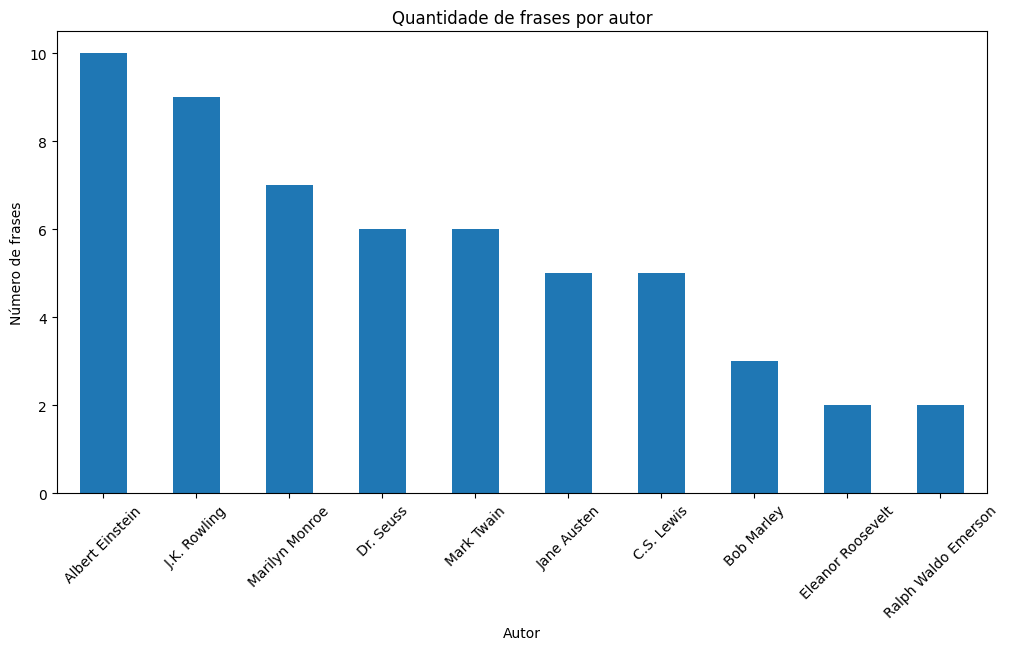

In [5]:
import matplotlib.pyplot as plt

contagem_autores = df["autor"].value_counts()

plt.figure(figsize=(12,6))
contagem_autores.head(10).plot(kind="bar")

plt.title("Quantidade de frases por autor")
plt.xlabel("Autor")
plt.ylabel("Número de frases")

plt.xticks(rotation=45)
plt.show()

### Tags mais citadas

tags
love             14
inspirational    13
life             13
humor            12
books            11
reading           7
friendship        5
friends           4
truth             4
simile            3
Name: count, dtype: int64


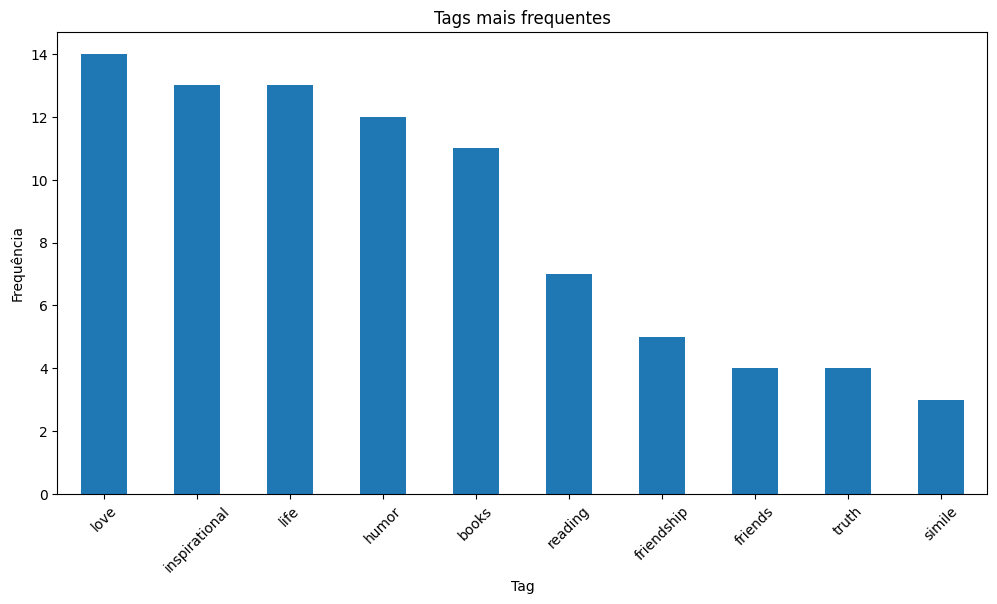

['change', 'deep-thoughts', 'thinking', 'world']
<class 'list'>


In [12]:
import ast
import ast

df["tags"] = df["tags"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

tags_explodidas = df.explode("tags")
contagem_tags = tags_explodidas["tags"].value_counts()

print(contagem_tags.head(10))
plt.figure(figsize=(12,6))
contagem_tags.head(10).plot(kind="bar")

plt.title("Tags mais frequentes")
plt.xlabel("Tag")
plt.ylabel("Frequência")

plt.xticks(rotation=45)
plt.show()

In [20]:
df["tags"].apply(type).value_counts()
tags_explodidas = df.explode("tags").reset_index(drop=True)

In [21]:
tabela_autor_tag = pd.crosstab(
    tags_explodidas["autor"],
    tags_explodidas["tags"]
)
contagem_autores = df["autor"].value_counts()

autores_relevantes = contagem_autores[
    contagem_autores >= 3
].index.tolist()


tabela_filtrada = tabela_autor_tag[
    tabela_autor_tag.index.isin(autores_relevantes)
]

In [35]:
#import seaborn as sns
#import matplotlib.pyplot as plt
#
#plt.figure(figsize=(14,8))
#
#sns.heatmap(
#    tabela_filtrada,
#    cmap="Blues",
#    annot=True
#)
#
#plt.title("Relação entre autores e tags")
#plt.xlabel("Tags")
#plt.ylabel("Autores")
#
#plt.show()

### Palavras mais frequentes
Visualização nuvem de palavras

[('love', 23), ('one', 15), ('never', 13), ('life', 12), ('think', 12), ('make', 10), ('like', 9), ('good', 8), ('live', 7), ('know', 7), ('day', 7), ('going', 7), ('give', 7), ('keep', 7), ('may', 7), ('people', 7), ('time', 7), ('book', 7), ('see', 7), ('world', 6)]


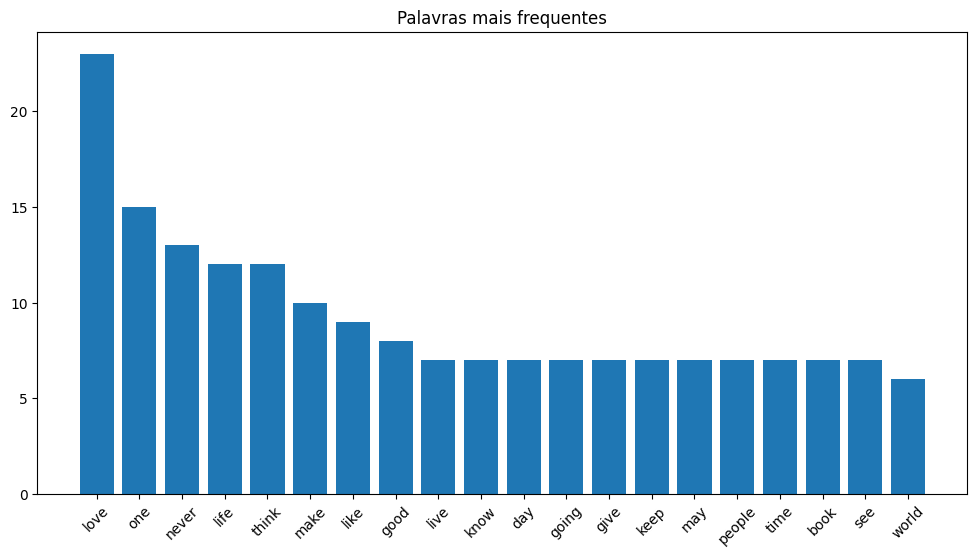

In [23]:
texto = " ".join(df["frase_sem_stopwords"])
palavras = texto.split()
from collections import Counter

frequencia = Counter(palavras)

print(frequencia.most_common(20))
top20 = frequencia.most_common(20)

palavras = [p[0] for p in top20]
freqs = [p[1] for p in top20]

plt.figure(figsize=(12,6))

plt.bar(palavras, freqs)

plt.title("Palavras mais frequentes")
plt.xticks(rotation=45)

plt.show()

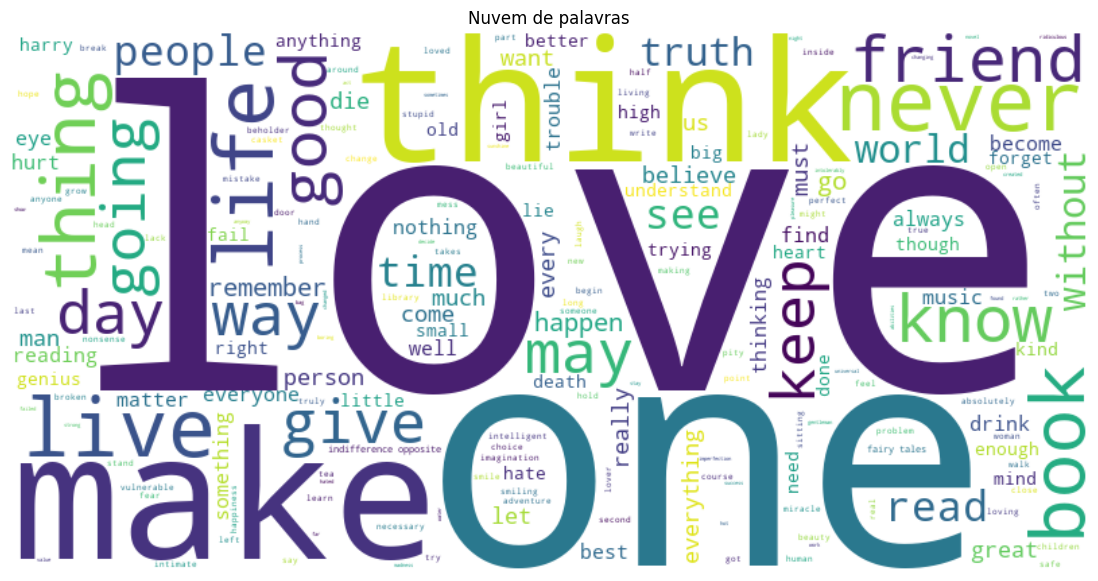

In [25]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(texto)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis("off")

plt.title("Nuvem de palavras")

plt.show()

### Palavras mais frequentes por autor

In [36]:
autores_relevantes = df["autor"].value_counts()

autores_relevantes = autores_relevantes[
    autores_relevantes >= 3
].index

from collections import Counter

for autor in autores_relevantes:

    print("\n")
    print("="*50)
    print(f"Autor: {autor}")

    frases_autor = df[
        df["autor"] == autor
    ]["frase_sem_stopwords"]

    texto_autor = " ".join(frases_autor)

    palavras_autor = texto_autor.split()

    frequencia_autor = Counter(palavras_autor)

    print(frequencia_autor.most_common(3))



Autor: Albert Einstein
[('life', 3), ('music', 3), ('thinking', 2)]


Autor: J.K. Rowling
[('harry', 3), ('great', 3), ('live', 3)]


Autor: Marilyn Monroe
[('make', 4), ('keep', 4), ('going', 3)]


Autor: Dr. Seuss
[('think', 5), ('troubles', 3), ('one', 2)]


Autor: Mark Twain
[('good', 2), ('life', 2), ('never', 2)]


Autor: Jane Austen
[('love', 3), ('lady', 2), ('really', 2)]


Autor: C.S. Lewis
[('enough', 3), ('love', 3), ('vulnerable', 2)]


Autor: Bob Marley
[('may', 4), ('give', 3), ('perfect', 2)]


### Tamanho das frases por autor (autores com pelo menos 3 frases)


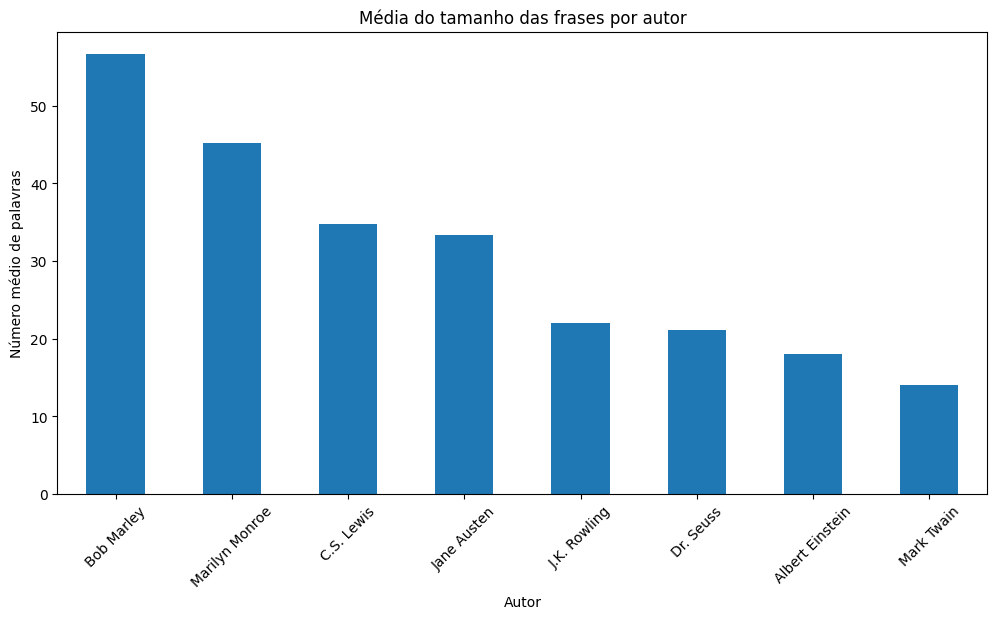

                 media_tamanho  quantidade_frases
autor                                            
Bob Marley           56.666667                  3
Marilyn Monroe       45.142857                  7
C.S. Lewis           34.800000                  5
Jane Austen          33.400000                  5
J.K. Rowling         22.000000                  9
Dr. Seuss            21.166667                  6
Albert Einstein      18.000000                 10
Mark Twain           14.000000                  6


In [32]:
df["tamanho_frase"] = df["frase"].apply(
    lambda x: len(x.split())
)

contagem_autores = df["autor"].value_counts()

autores_relevantes = contagem_autores[
    contagem_autores >= 3
].index

media_tamanho = (
    df[df["autor"].isin(autores_relevantes)]
    .groupby("autor")["tamanho_frase"]
    .mean()
    .sort_values(ascending=False)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

media_tamanho.plot(kind="bar")

plt.title("Média do tamanho das frases por autor")
plt.xlabel("Autor")
plt.ylabel("Número médio de palavras")

plt.xticks(rotation=45)

plt.show()

estatisticas_autores = (
    df[df["autor"].isin(autores_relevantes)]
    .groupby("autor")
    .agg(
        media_tamanho=("tamanho_frase", "mean"),
        quantidade_frases=("frase", "count")
    )
    .sort_values(by="media_tamanho", ascending=False)
)

print(estatisticas_autores)

### Tsne Thiago

In [37]:
df_bow = pd.read_csv("df_bow.csv")
df_tfidf = pd.read_csv("TF_IDF.csv")

print(f"BoW:    {df_bow.shape}")
print(f"TF-IDF: {df_tfidf.shape}")
df_bow.head()

BoW:    (100, 560)
TF-IDF: (100, 559)


,frase,autor,tags,bow_abilities,bow_absolutely,bow_absurdities,bow_accept,bow_across,bow_act,bow_actually,...,bow_would,bow_wrap,bow_write,bow_writing,bow_written,bow_wrote,bow_wrung,bow_year,bow_youer,palavras_unicas
0,“The world as we have created it is a process ...,Albert Einstein,"['change', 'deep-thoughts', 'thinking', 'world']",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"['abilities', 'choices']",1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
2,“There are only two ways to live your life. On...,Albert Einstein,"['inspirational', 'life', 'live', 'miracle', '...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"['aliteracy', 'books', 'classic', 'humor']",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"['be-yourself', 'inspirational']",0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8


In [42]:
colunas_bow = [c for c in df_bow.columns if c.startswith("bow_")]
colunas_tfidf = [c for c in df_tfidf.columns if c.startswith("tfidf_")]

X_bow = df_bow[colunas_bow].values
X_tfidf = df_tfidf[colunas_tfidf].values

titulos = df_bow["frase"].tolist()

print(f"X_bow:   {X_bow.shape}")
print(f"X_tfidf: {X_tfidf.shape}")

X_bow:   (100, 556)
X_tfidf: (100, 556)


In [14]:
perplexity = 50
random_state = 42

tsne_bow = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, init="random")
embed_bow = tsne_bow.fit_transform(X_bow)

tsne_tfidf = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, init="random")
embed_tfidf = tsne_tfidf.fit_transform(X_tfidf)

print("embed_bow:  ", embed_bow.shape)
print("embed_tfidf:", embed_tfidf.shape)

embed_bow:   (100, 2)
embed_tfidf: (100, 2)


In [16]:
def plotar(embed, nome):
    df_plot = pd.DataFrame({
        "x": embed[:, 0],
        "y": embed[:, 1],
        "indice": df_bow.index,
        "frase": df_bow["frase"],
        "autor": df_bow["autor"],
        "tags": df_bow["tags"],

    })
    fig = px.scatter(
        df_plot,
        x="x",
        y="y",
        hover_data={"indice": True, "frase": True,"tags": True, "autor": True, "x": False, "y": False},
        title=f"t-SNE - {nome}",
        width=700,
        height=700,
    )
    fig.write_html(nome+".html")
    fig.show()


plotar(embed_bow, "Bag of Words")
plotar(embed_tfidf, "TF-IDF")

### Analise palavras mais importantes por autor 

In [44]:
contagem_autores = df_tfidf["autor"].value_counts()

autores_relevantes = contagem_autores[
    contagem_autores >= 3
].index

tfidf_filtrado = df_tfidf[
    df_tfidf["autor"].isin(autores_relevantes)
]

colunas_texto = ["autor", "frase", "tags"]

colunas_tfidf = [
    col for col in tfidf_filtrado.columns
    if col not in colunas_texto
]

media_tfidf_autor = (
    tfidf_filtrado
    .groupby("autor")[colunas_tfidf]
    .mean()
)

for autor in media_tfidf_autor.index:

    print("\n")
    print("="*50)
    print(f"Autor: {autor}")

    top_palavras = (
        media_tfidf_autor.loc[autor]
        .sort_values(ascending=False)
        .head(10)
    )

    print(top_palavras)



Autor: Albert Einstein
tfidf_understand    0.157795
tfidf_get           0.128755
tfidf_fool          0.115129
tfidf_point         0.097801
tfidf_six           0.092103
tfidf_logic         0.092103
tfidf_year          0.092103
tfidf_explain       0.092103
tfidf_everywhere    0.092103
tfidf_become        0.087664
Name: Albert Einstein, dtype: float64


Autor: Bob Marley
tfidf_hits         0.219294
tfidf_pain         0.219294
tfidf_music        0.186287
tfidf_feel         0.186287
tfidf_suffering    0.170562
tfidf_worth        0.170562
tfidf_got          0.144890
tfidf_ones         0.144890
tfidf_thing        0.142654
tfidf_hurt         0.140256
Name: Bob Marley, dtype: float64


Autor: C.S. Lewis
tfidf_enough          0.268253
tfidf_best            0.173868
tfidf_believe         0.143061
tfidf_start           0.131576
tfidf_see             0.125040
tfidf_tales           0.111772
tfidf_fairy           0.111772
tfidf_doubting        0.102337
tfidf_christianity    0.102337
tfidf_necessari

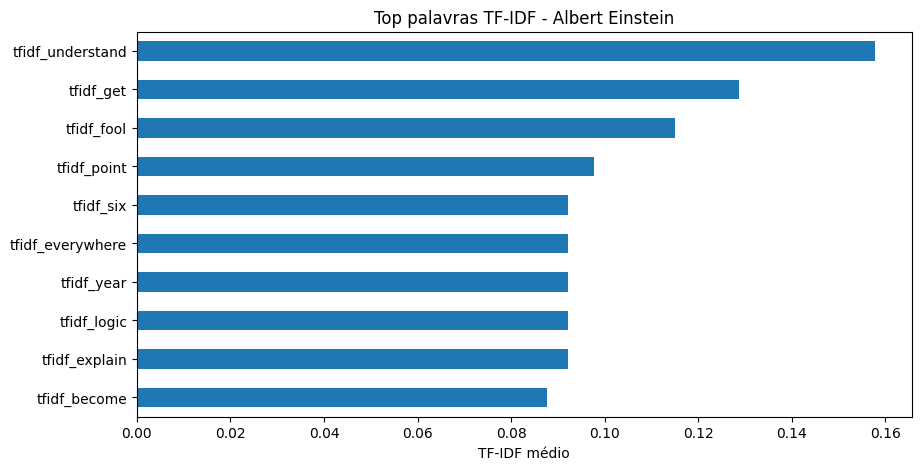

In [40]:
autor = "Albert Einstein"

top_palavras = (
    media_tfidf_autor.loc[autor]
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_palavras.sort_values().plot(kind="barh")

plt.title(f"Top palavras TF-IDF - {autor}")
plt.xlabel("TF-IDF médio")

plt.show()

### Existem grupos naturais de frases semelhantes?

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
)
X = vectorizer.fit_transform(
    df["frase_sem_stopwords"]
)


In [76]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [78]:
df["cluster"] = kmeans.labels_
#for cluster in range(4):
#
#    print("\n")
#    print("="*60)
#    print(f"CLUSTER {cluster}")
#
#    frases_cluster = df[
#        df["cluster"] == cluster
#    ]["frase"]
#    for frase in frases_cluster.head(5):
#        print("-", frase)

import pandas as pd

termos = vectorizer.get_feature_names_out()

for i in range(2):

    print("\n")
    print("="*50)
    print(f"CLUSTER {i}")

    centroide = kmeans.cluster_centers_[i]

    indices = centroide.argsort()[-10:][::-1]

    palavras = [termos[indice] for indice in indices]

    print(palavras)



CLUSTER 0
['love', 'one', 'life', 'like', 'never', 'think', 'know', 'read', 'time', 'people']


CLUSTER 1
['truth', 'get', 'hurt', 'better', 'lie', 'never', 'loved', 'hated', 'absolutely', 'enough']


- Reflexão, conhecimento e introspecção
- Emoções e verdade
- Criatividade e expressão
- Vida cotidiana e experiências humanas

k=4

- Reflexões sobre vida e conhecimento
- Emoções e relacionamentos
- Pensamento e expressão

k=3 

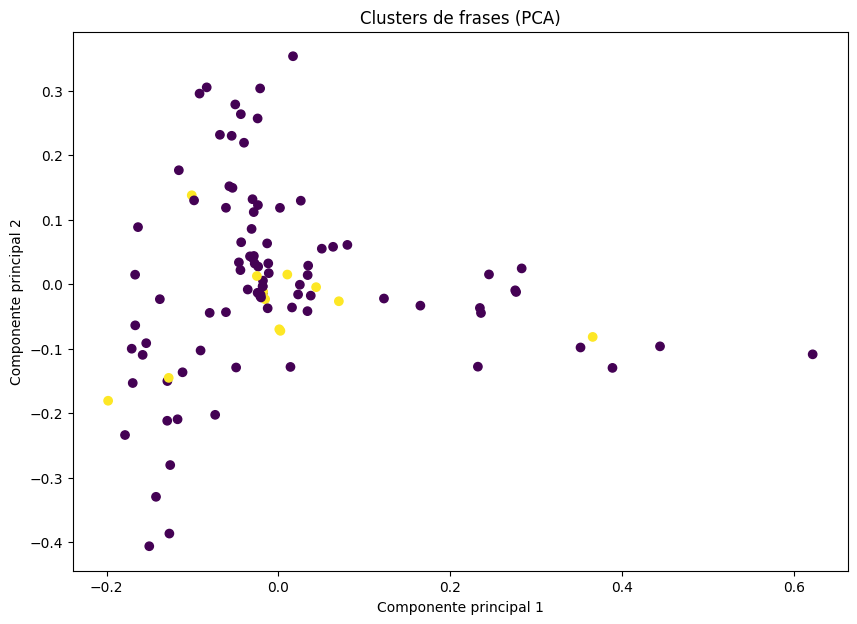

In [79]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X.toarray())

import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["cluster"]
)

plt.title("Clusters de frases (PCA)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

plt.show()

In [82]:
pd.crosstab(df["cluster"], df["autor"])

autor,Albert Einstein,Alexandre Dumas fils,Alfred Tennyson,Allen Saunders,André Gide,Ayn Rand,Bob Marley,C.S. Lewis,Charles Bukowski,Charles M. Schulz,...,Mother Teresa,Pablo Neruda,Ralph Waldo Emerson,Stephenie Meyer,Steve Martin,Suzanne Collins,Terry Pratchett,Thomas A. Edison,W.C. Fields,William Nicholson
cluster,,,,,,,,,,,,,,,,,,,,,
0,9,1,1,1,0,1,1,4,2,0,...,2,1,2,1,1,2,1,1,1,1
1,1,0,0,0,1,0,2,1,0,1,...,0,0,0,0,0,0,0,0,0,0
